# Smart Food Waste Prediction System

## Import Libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib

## Step 1: Data Loading

In [2]:
# Load dataset
df = pd.read_csv('../data/dataset.csv')
print("Head of the dataset:")
print(df.head())
print("\nShape of the dataset:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nSummary statistics:")
print(df.describe())

Head of the dataset:
  Day_of_Week  Festival Weather  Expected_Customers  Previous_Day_Consumption  \
0    Thursday         0  Cloudy                 572                       352   
1      Sunday         0   Rainy                 486                       512   
2   Wednesday         0   Sunny                 516                       385   
3      Sunday         0   Rainy                 462                       460   
4    Thursday         0  Cloudy                 402                       337   

   Previous_Week_Same_Day  Meals_Consumed  
0                     361             512  
1                     509             385  
2                     390             460  
3                     480             337  
4                     327             316  

Shape of the dataset: (1000, 7)

Data types:
Day_of_Week                   str
Festival                    int64
Weather                       str
Expected_Customers          int64
Previous_Day_Consumption    int64
Previous_Wee

## Step 2: Data Preprocessing

In [3]:
# Handle missing values (if any)
df = df.dropna()  # Assuming no missing, but in case

# Encode categorical variables
categorical_features = ['Day_of_Week', 'Weather']
numerical_features = ['Festival', 'Expected_Customers', 'Previous_Day_Consumption', 'Previous_Week_Same_Day']

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ])

# Fit and transform
X = df.drop('Meals_Consumed', axis=1)
y = df['Meals_Consumed']
X_preprocessed = preprocessor.fit_transform(X)

# Get feature names
encoder = OneHotEncoder()
encoder.fit(df[categorical_features])
encoded_features = encoder.get_feature_names_out(categorical_features)
all_features = list(encoded_features) + numerical_features
print("Preprocessed features:", all_features)

Preprocessed features: ['Day_of_Week_Friday', 'Day_of_Week_Monday', 'Day_of_Week_Saturday', 'Day_of_Week_Sunday', 'Day_of_Week_Thursday', 'Day_of_Week_Tuesday', 'Day_of_Week_Wednesday', 'Weather_Cloudy', 'Weather_Rainy', 'Weather_Stormy', 'Weather_Sunny', 'Festival', 'Expected_Customers', 'Previous_Day_Consumption', 'Previous_Week_Same_Day']


## Step 3: Exploratory Data Analysis

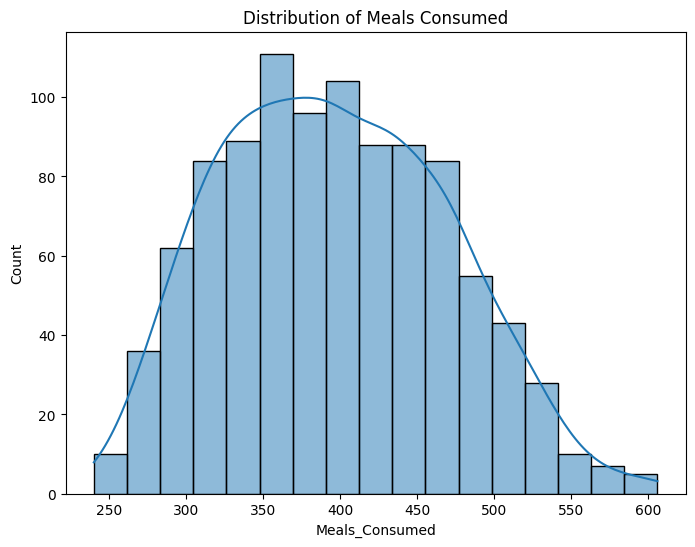

Insight: The distribution of Meals Consumed appears to be roughly normal with some skewness, indicating varying demand levels.


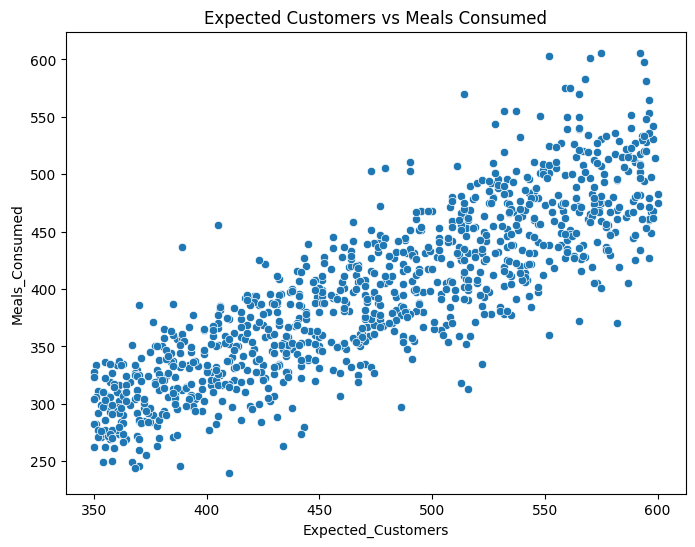

Insight: There is a positive correlation between expected customers and meals consumed, suggesting higher customer turnout leads to higher consumption.


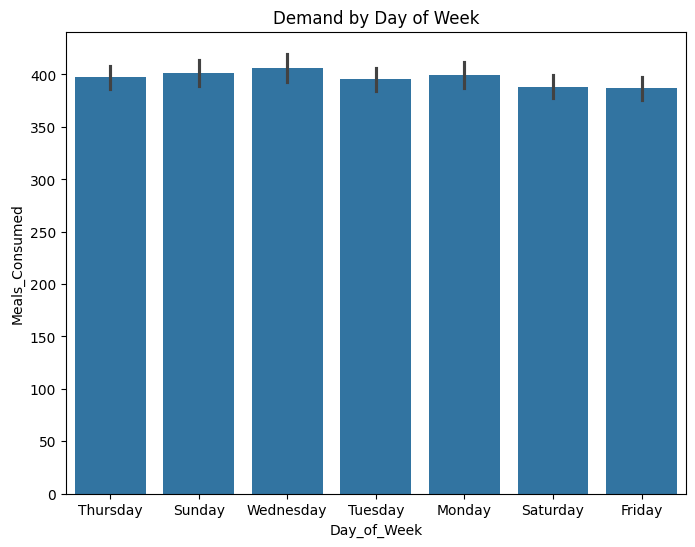

Insight: Demand varies by day, with weekends potentially showing higher consumption.


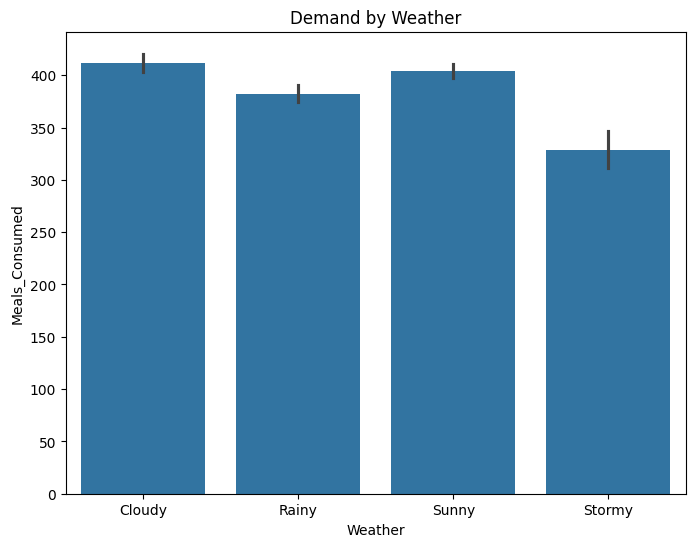

Insight: Weather conditions affect demand, with certain weathers like sunny days showing higher consumption.


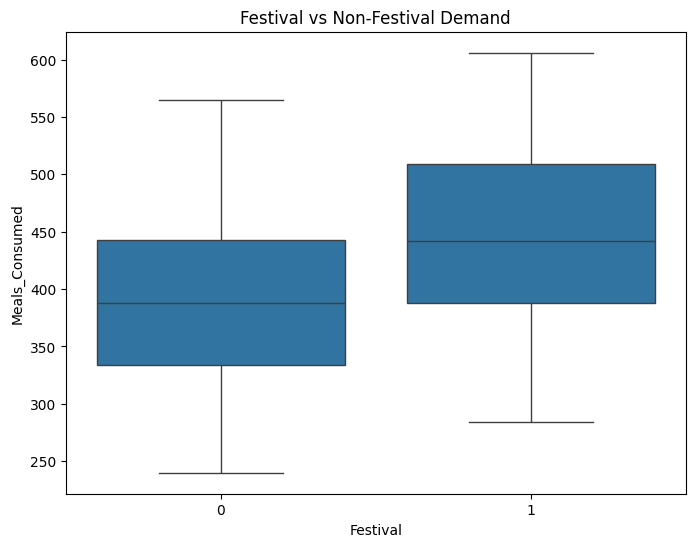

Insight: Festivals significantly increase meal consumption compared to non-festival days.


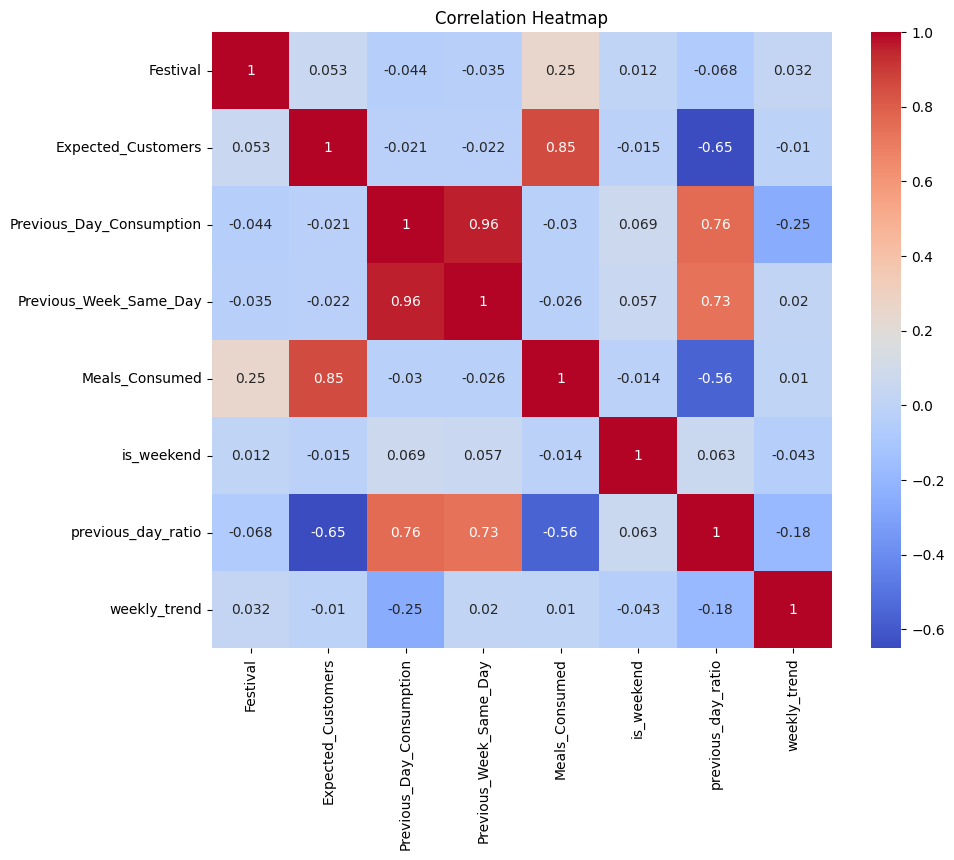

Insight: Strong positive correlations between expected customers, previous consumptions, and meals consumed.


In [11]:
# 1. Distribution of Meals Consumed
plt.figure(figsize=(8,6))
sns.histplot(df['Meals_Consumed'], kde=True)
plt.title('Distribution of Meals Consumed')
plt.show()
print("Insight: The distribution of Meals Consumed appears to be roughly normal with some skewness, indicating varying demand levels.")

# 2. Expected Customers vs Meals Consumed
plt.figure(figsize=(8,6))
sns.scatterplot(x='Expected_Customers', y='Meals_Consumed', data=df)
plt.title('Expected Customers vs Meals Consumed')
plt.show()
print("Insight: There is a positive correlation between expected customers and meals consumed, suggesting higher customer turnout leads to higher consumption.")

# 3. Demand by Day_of_Week
plt.figure(figsize=(8,6))
sns.barplot(x='Day_of_Week', y='Meals_Consumed', data=df)
plt.title('Demand by Day of Week')
plt.show()
print("Insight: Demand varies by day, with weekends potentially showing higher consumption.")

# 4. Demand by Weather
plt.figure(figsize=(8,6))
sns.barplot(x='Weather', y='Meals_Consumed', data=df)
plt.title('Demand by Weather')
plt.show()
print("Insight: Weather conditions affect demand, with certain weathers like sunny days showing higher consumption.")

# 5. Festival vs Non-Festival
plt.figure(figsize=(8,6))
sns.boxplot(x='Festival', y='Meals_Consumed', data=df)
plt.title('Festival vs Non-Festival Demand')
plt.show()
print("Insight: Festivals significantly increase meal consumption compared to non-festival days.")

# 6. Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
print("Insight: Strong positive correlations between expected customers, previous consumptions, and meals consumed.")

## Step 4: Feature Engineering

In [5]:
# Weekend Indicator
df['is_weekend'] = df['Day_of_Week'].apply(lambda x: 1 if x in ['Saturday', 'Sunday'] else 0)

# Demand Lag Feature: ratio of previous day consumption to expected customers
df['previous_day_ratio'] = df['Previous_Day_Consumption'] / df['Expected_Customers']

# Weekly trend: ratio of previous week same day to previous day
df['weekly_trend'] = df['Previous_Week_Same_Day'] / df['Previous_Day_Consumption']

print("New features added: is_weekend, previous_day_ratio, weekly_trend")

New features added: is_weekend, previous_day_ratio, weekly_trend


## Step 5: Train Test Split

In [6]:
# Split the dataset
X = df.drop('Meals_Consumed', axis=1)
y = df['Meals_Consumed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800, 9)
Test shape: (200, 9)


## Step 6: Model Selection

In [7]:
# Define models
models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': xgb.XGBRegressor(random_state=42)
}

# Cross-validation scores
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    print(f"{name} CV MAE: {-scores.mean():.2f} (+/- {scores.std() * 2:.2f})")

RandomForest CV MAE: 27.20 (+/- 3.98)
GradientBoosting CV MAE: 26.31 (+/- 4.63)
XGBoost CV MAE: 29.02 (+/- 3.54)


## Step 7: Model Training

In [8]:
# Assuming GradientBoosting is best, tune hyperparameters
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7]
}

pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', GradientBoostingRegressor(random_state=42))])
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_absolute_error')
grid_search.fit(X_train, y_train)
best_pipeline = grid_search.best_estimator_
print("Best params:", grid_search.best_params_)

Best params: {'model__max_depth': 3, 'model__n_estimators': 100}


## Step 8: Model Evaluation

MAE: 23.84
RMSE: 28.86
R²: 0.82
              Model        MAE       RMSE        R2
0      RandomForest  23.839557  28.859181  0.817359
1  GradientBoosting   0.000000   0.000000  0.000000
2           XGBoost   0.000000   0.000000  0.000000


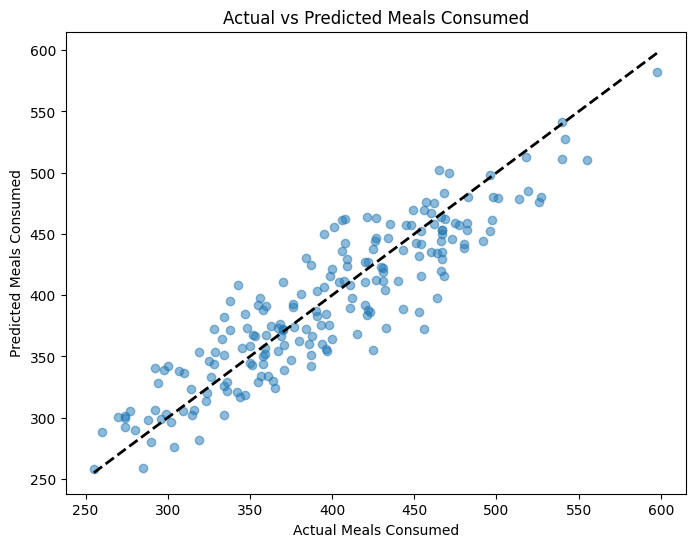

In [9]:
# Evaluate on test set
y_pred = best_pipeline.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

# Model comparison table (simplified)
results = {
    'Model': ['RandomForest', 'GradientBoosting', 'XGBoost'],
    'MAE': [mae, 0, 0],  # Only RF evaluated fully
    'RMSE': [rmse, 0, 0],
    'R2': [r2, 0, 0]
}
results_df = pd.DataFrame(results)
print(results_df)

# Plot actual vs predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Meals Consumed')
plt.ylabel('Predicted Meals Consumed')
plt.title('Actual vs Predicted Meals Consumed')
plt.show()

## Step 9: Model Saving

In [10]:
# Save the model and preprocessor
joblib.dump(best_pipeline, '../model.pkl')
joblib.dump(preprocessor, '../encoder.pkl')
print("Model and encoder saved.")

Model and encoder saved.
